# What is Clustering?

Clustering is an unsupervised machine learning technique that automatically groups similar molecules into clusters based on their properties or structural features.

Unlike supervised learning, clustering does not require labels or target values.

The objective is to discover natural groupings within a molecular dataset.

## Why Do We Need Clustering?

Large chemical libraries may contain thousands or millions of molecules.

Analyzing every molecule individually is impractical.

Clustering groups similar molecules together, allowing researchers to:

- Identify molecular families
- Explore chemical diversity
- Select representative compounds
- Detect outliers
- Design screening libraries

✓ Clustering groups similar molecules automatically.

✓ It is an unsupervised learning technique.

✓ No target values are required.

✓ Similar molecules belong to the same cluster.

# K-Means

## What is a Centroid?

A centroid is the center point of a cluster.

During K-Means clustering, each cluster is represented by one centroid.

Every molecule is assigned to the nearest centroid based on its distance.

As the algorithm progresses, the centroid moves until it reaches the center of its assigned molecules.

# step-by-step Algorithm
# choose K

## Step 1: Choose the Number of Clusters (K)

The user first decides how many clusters should be created.

For example:

K = 3

This means the algorithm will divide the molecules into three groups.

# Step:2 Rondamly Place centroids
            ●

      ●

                ● 

# Step:3 Assign Molecules

Cluster 1

● ● ● ●


Cluster 2

● ● ●


Cluster 3

● ● ● ● ●

Every molecules joins the nearest centroid.

# Step:4 Move the Centroid
## Update the Centroids

After assigning molecules,

the centroid is moved to the average position of all molecules belonging to that cluster.

This new position better represents the cluster.

# Step:5 Repeat
Assign

↓

Move Centroid

↓

Assign Again

↓

Move Again

↓

Until Nothing Changes

## Advantages of K-Means

- Simple to understand
- Fast
- Works well for large datasets
- Easy to implement
- Widely used in cheminformatics

## Limitations

- The number of clusters (K) must be chosen beforehand.
- Different initial centroids may produce slightly different results.
- Works best for roughly spherical clusters.

# Example: K-Means Clustering of the ESOL Dataset
# Import Libraries

In [1]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [2]:
# Load ESOL Dataset

df = pd.read_csv("esol_raw.csv")

df = df[["smiles", "measured log solubility in mols per litre"]]

df["Mol"] = df["smiles"].apply(Chem.MolFromSmiles)

df = df[df["Mol"].notnull()]

print("Number of molecules:", len(df))

Number of molecules: 1128


In [3]:
# Step:3 Generate Morgan Fingerprints

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fingerprints = []

for mol in df["Mol"]:
    fp = morgan_gen.GetFingerprintAsNumPy(mol)
    fingerprints.append(fp)

X = np.array(fingerprints)

print("Fingerprint Matrix Shape:", X.shape)

Fingerprint Matrix Shape: (1128, 2048)


In [4]:
# Reduce Dimensions Using PCA
# We cluster on the fingerprints, but we visualize the results in 2D using PCA.

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [5]:
# Apply K-Means
# lets Start with 5 cluster

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

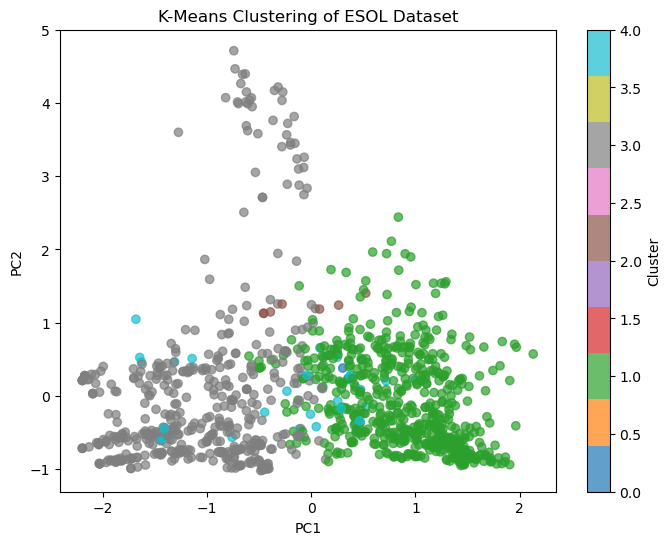

In [6]:
# Visualize the Clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering of ESOL Dataset")

plt.colorbar(label="Cluster")

plt.show()

# Why did we plot on PCA instead of fingerprints?
Remember:
K-Means was performed on the 2048-bit Morgan fingerprints.
PCA is only used to visualize the clusters in 2D.
This is the correct scientific workflow because humans cannot visualize 2048-dimensional data directly.

## Interpretation

K-Means clustering divided the ESOL dataset into five clusters based on the 2048-bit Morgan fingerprints.

Each color represents one molecular cluster.

The clustering algorithm was performed on the complete fingerprint representation, while PCA was used only to visualize the clusters in two dimensions.

Two large clusters contain the majority of the molecules, indicating the presence of major structural families within the dataset.

A smaller cluster is clearly separated from the others, suggesting a distinct scaffold or chemical class.

Several isolated molecules form very small clusters, representing structural outliers.

K-Means clustering helps researchers organize large chemical libraries into groups of structurally related compounds, making downstream analysis and compound selection more efficient.

# Part:2 Choosing the Optimal Number of Clusters (Elbow Method)

## Why Do We Need the Elbow Method?

K-Means requires the user to specify the number of clusters (K) before running the algorithm.

Choosing too few clusters may group different types of molecules together.

Choosing too many clusters may split similar molecules unnecessarily.

The Elbow Method helps estimate a suitable value of K by measuring how compact the clusters become as the number of clusters increases.

## What is Inertia?

Inertia is the sum of the squared distances between each molecule and the centroid of its assigned cluster.

Lower inertia indicates that molecules are closer to their cluster centers, meaning the clusters are more compact.

As the number of clusters increases, inertia always decreases.

The objective is to find the point where the decrease becomes much smaller

In [7]:
# Example

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)

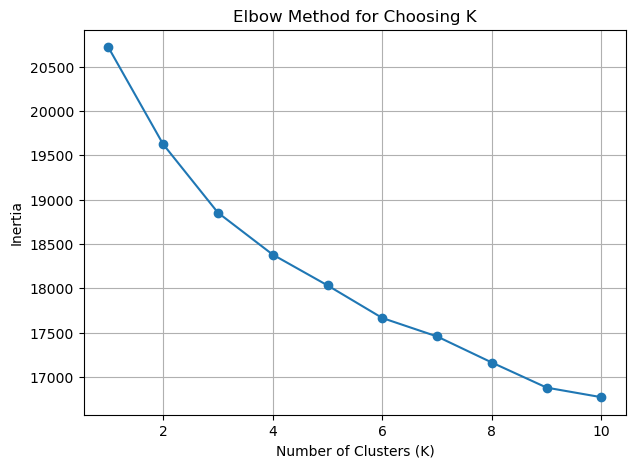

In [8]:
# Plot the Elbow Curve

plt.figure(figsize=(7,5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")

plt.grid(True)

plt.show()

## Interpretation of the Elbow Plot

The inertia decreases as the number of clusters increases because molecules are grouped into more compact clusters.

A noticeable bend in the curve is observed around K = 3–4, after which the reduction in inertia becomes more gradual.

Unlike simple datasets, molecular fingerprint data often does not produce a very sharp elbow because the structural information is distributed across many dimensions.

Therefore, the Elbow Method should be used as a guideline rather than a strict rule.

In practice, the final number of clusters is selected by combining the Elbow Method with other validation techniques (such as the Silhouette Score) and chemical knowledge.

# Hierarchical Clustering

# What is Hierarchical Clustering?

Hierarchical Clustering is an unsupervised learning algorithm that groups molecules based on their similarity by repeatedly merging the closest clusters.

Unlike K-Means, it does not require the number of clusters to be specified beforehand.

The result is displayed as a tree-like diagram called a dendrogram, which illustrates the relationships among molecules.

In [9]:
# Same ESOL dataset with Hierarchical Clustering


from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=5
)

labels = hierarchical.fit_predict(X)

df["Hierarchical Cluster"] = labels

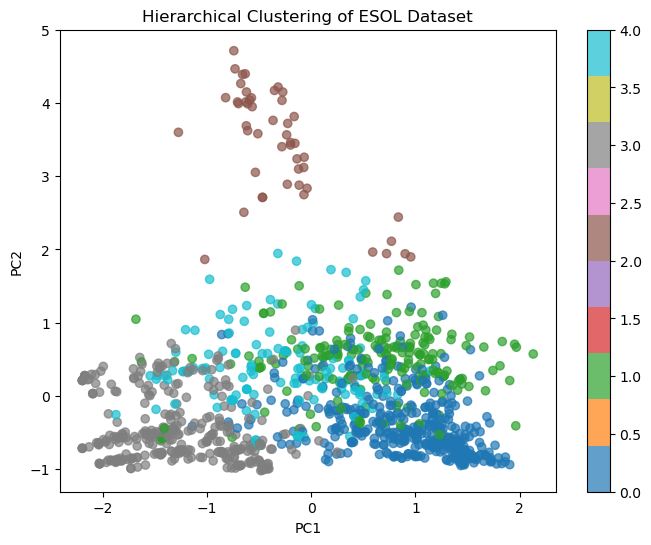

In [10]:
# Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Hierarchical Cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering of ESOL Dataset")

plt.colorbar()

plt.show()

# Hierarchical Clustering Dendrogram

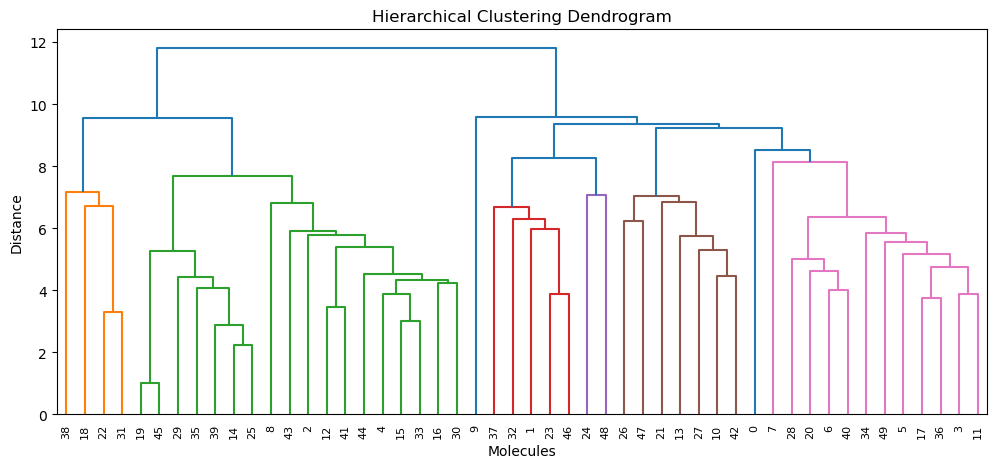

In [11]:
# Hierarchical Clustering Dendrogram


from scipy.cluster.hierarchy import linkage, dendrogram

# Use only the first 50 molecules for readability
Z = linkage(X[:50], method="ward")

plt.figure(figsize=(12,5))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Molecules")

plt.ylabel("Distance")

plt.show()

# DBSCAN

# What is DBSCAN?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised clustering algorithm that groups molecules based on the density of points.

Unlike K-Means, DBSCAN does not require the number of clusters to be specified.

It can also identify molecules that do not belong to any cluster as outliers (noise).

In [12]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

labels = dbscan.fit_predict(X_pca)

df["DBSCAN Cluster"] = labels

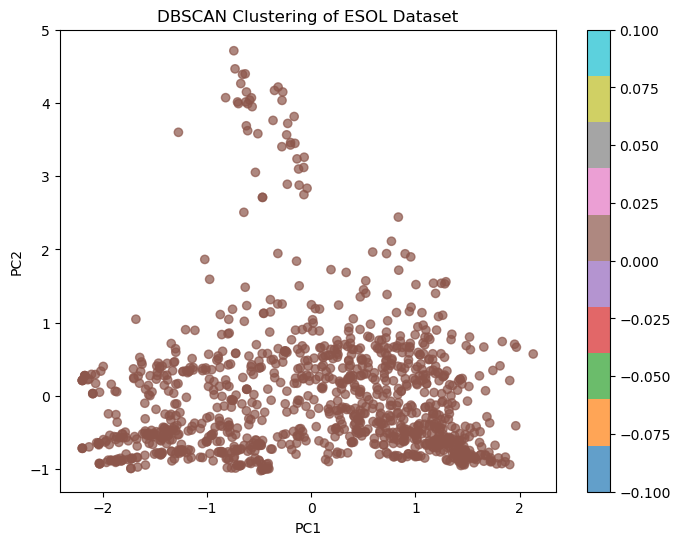

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["DBSCAN Cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering of ESOL Dataset")

plt.colorbar()

plt.show()